In [5]:
# Ejemplo de Clustering K-Means y Clustering jerárquico
# Importar librerías 

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# define la función para representar gráficos de características pareadas para los clústeres
def show_clusters_on_plot(df, x_name, y_name, cluster_name):
    plt.figure(figsize=(10, 10))
    sns.scatterplot(
        x=df[x_name],
        y=df[y_name],
        hue=df[cluster_name],
        palette='Paired'
    )
    plt.title(f'{x_name} vs {y_name}')
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.legend(title=cluster_name, loc='best')
    plt.tight_layout()
    plt.show()

In [7]:
# Leer datos
file_path = "C:/Git/vehicles_env/datasets/tripadvisor_review_case_us.csv"
travel = pd.read_csv(file_path) # Cargar dataframe
print(travel.shape) # Mostrar el tamaño del dataframe

(980, 10)


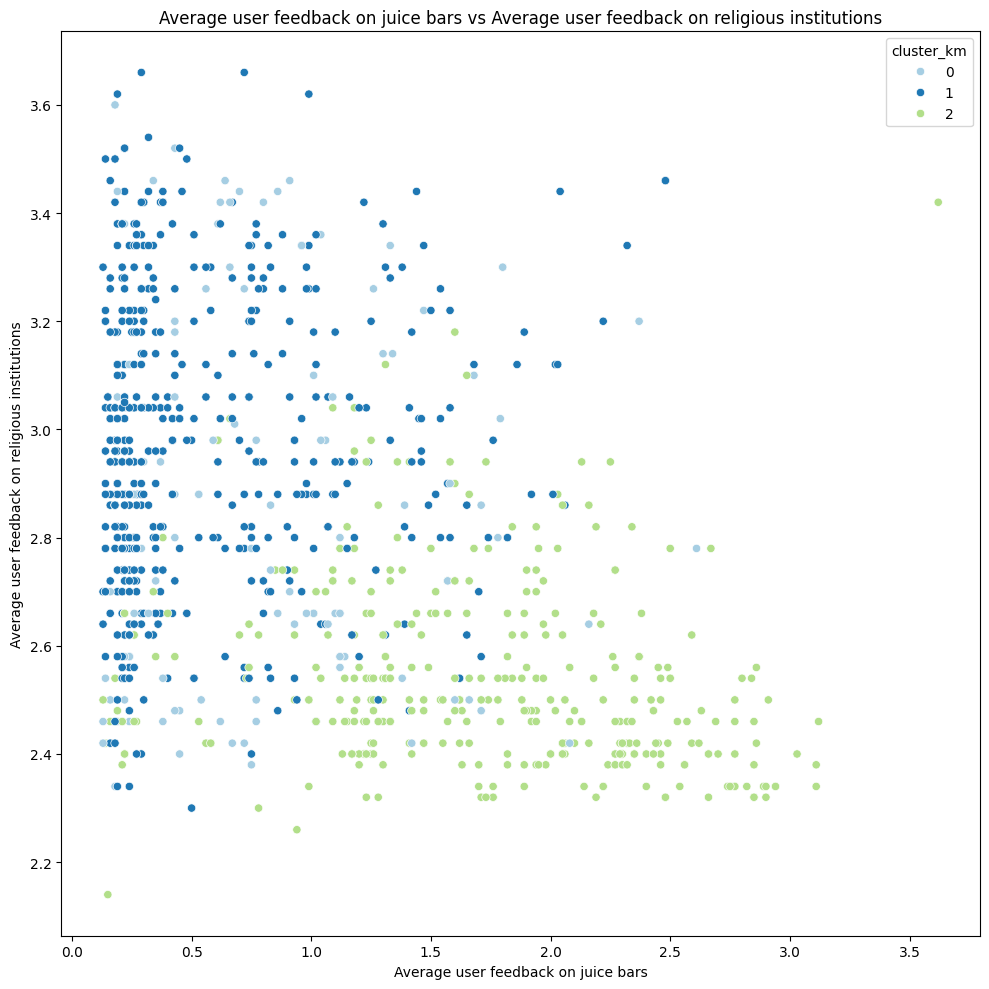

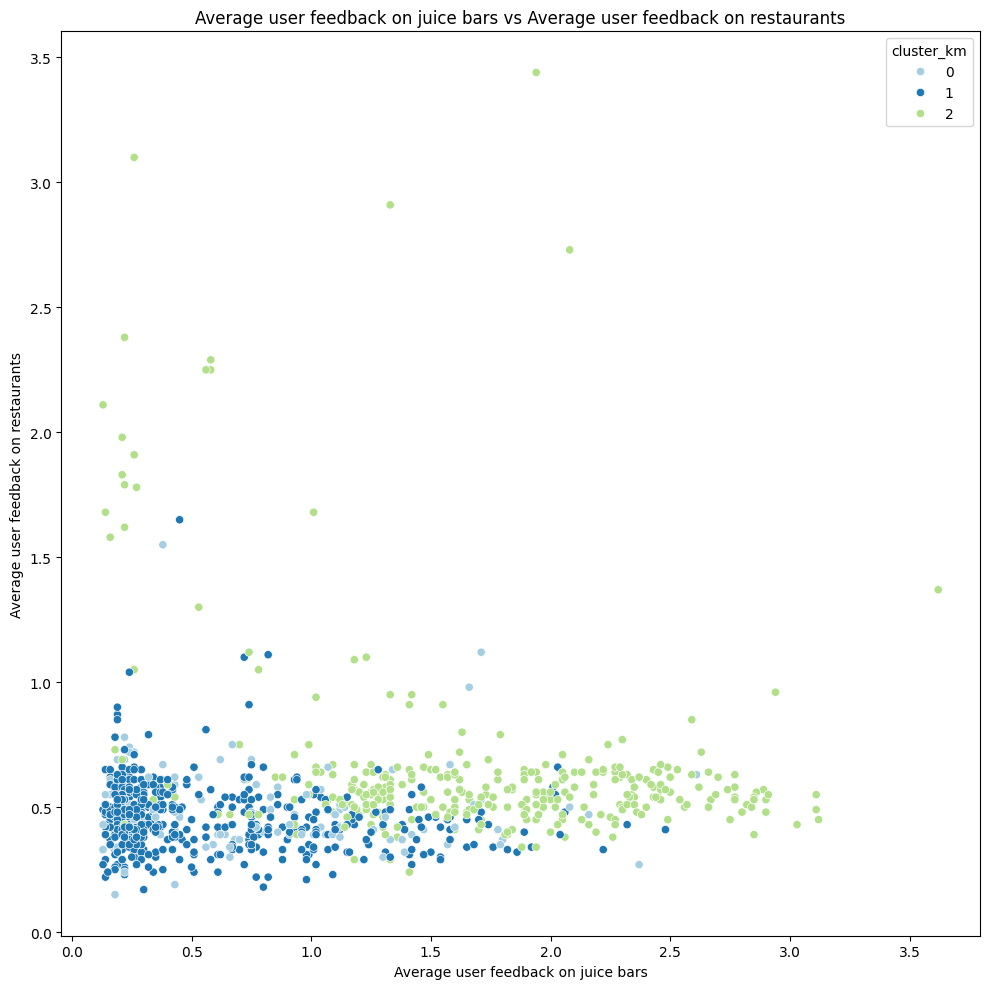

In [ ]:
# Al utilizar K-Means o Clustering jerárquico es indispensable estandarizar primero los datos

sc = StandardScaler() # Definir el modelo 
X_sc = sc.fit_transform(travel) # Estandarizar los datos

km = KMeans(n_clusters = 3) # Definir el número de clusters
labels = km.fit_predict(X_sc) # predice la cantidad de clusters para las observaciones.

travel['cluster_km'] = labels # Agregar las distancias en una nueva columna.

cluster_means = travel.groupby('cluster_km').mean().sort_index() # Obtener los valores medios por cluster
#print("\nMedias por clúster:", cluster_means)

# Graficar las características pareadas de "barra de juegos" y "religion"
show_clusters_on_plot(travel, 'Average user feedback on juice bars', 'Average user feedback on religious institutions', 'cluster_km')

# Graficar las características pareadas de "barra de juegos" y "restaurantes"
show_clusters_on_plot(travel, 'Average user feedback on juice bars', 'Average user feedback on restaurants', 'cluster_km')

¡Es correcto!

Los parámetros de los bares de jugos y de las instituciones religiosas resultaron ser características limítrofes para los clústeres. Como podemos ver en el gráfico pareado de estas variables, los grupos apenas se intersecan.

En cambio, el resto de parámetros son bastante similares y no difieren tanto: las playas son igualmente exóticas, y las galerías y los teatros no reciben altas calificaciones de estos/as viajeros/as exigentes.

Excelente bro 🙌, justo aquí es donde hay que bajar el lenguaje técnico y hacerlo digerible para un cliente. Te paso cómo explicarlo en **términos simples, claros y “de negocio”**:

---

### 👉 Cómo leer las gráficas

1. **Cada puntito es un cliente**:
   Representa la opinión promedio que un cliente dio en dos aspectos (por ejemplo, “juice bars” y “religión”).

2. **Los colores son grupos de clientes con comportamientos parecidos**:
   El algoritmo juntó a los clientes que califican parecido y los pintó del mismo color.

3. **El eje X y el eje Y son las variables comparadas**:

   * En la primera gráfica: calificaciones de *juice bars* (abajo) vs. *instituciones religiosas* (a la izquierda).
   * En la segunda gráfica: calificaciones de *juice bars* (abajo) vs. *restaurantes* (a la izquierda).

---

### 👉 Qué le decimos al cliente

* **“Aquí no hay una sola forma de opinar”**, sino que los usuarios se dividen en **segmentos claros**.
* **Algunos valoran más lo religioso** y ponen bajas notas a juice bars.
* **Otros muestran interés más diverso por lo gastronómico** (juice bars y restaurantes), aunque con calificaciones más bajas en religión.
* **Esto significa que el mercado no es uniforme**: hay subgrupos de clientes con intereses distintos, y a cada uno se le puede hablar con un mensaje diferente.

---

### 👉 Ejemplo de discurso simple

> “Lo que vemos en estas gráficas es que no todos los usuarios piensan igual. El color de cada grupo nos muestra que hay clientes con patrones distintos: unos ponen más atención a temas religiosos, otros a los bares de jugos o restaurantes. En lugar de ver a los clientes como un solo bloque, estas divisiones nos permiten entender qué busca cada segmento y, con eso, diseñar estrategias más personalizadas para cada uno.”

---